In [3]:
# Imports all necessary libraries for:
# - Loading and handling images (PIL, os, pathlib)
# - Using Stable Diffusion pipelines (diffusers)
# - Calculating FID score for image quality evaluation (cleanfid)
# - Computing CLIPScore for text-image alignment (CLIP)
# - Image transformations for model compatibility (torchvision.transforms)
# - Measuring perceptual similarity between images (LPIPS)
# - Plotting and visualizing results (matplotlib)

from PIL import Image
import os
from pathlib import Path
import torch
from diffusers import StableDiffusionPipeline
from cleanfid import fid
import clip
from PIL import Image, ImageEnhance, ImageFilter
from tqdm import tqdm
from torchvision import transforms
import lpips 
import matplotlib.pyplot as plt
import cv2
import numpy as np


In [4]:
# Paths
raw_dir = Path("data/rawData")
aug_dir = Path("data/augmentedData/unspecified")
output_dir = Path("chikankari_final_dataset")
output_dir.mkdir(parents=True, exist_ok=True)

# Collect all image paths
image_paths = list(raw_dir.glob("*.jpg")) + list(raw_dir.glob("*.png")) + \
              list(aug_dir.glob("*.jpg")) + list(aug_dir.glob("*.png"))

print(f"Found {len(image_paths)} images.")

# Function to check if image is blurry
def is_blurry(image, threshold=100.0):
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold  # True if blurry

# Resize, filter, and save
saved_count = 0
skipped_count = 0
for i, img_path in enumerate(image_paths):
    try:
        img = Image.open(img_path).convert("RGB")
        if is_blurry(img):
            skipped_count += 1
            continue
        img = img.resize((512, 512))
        save_path = output_dir / f"image_{saved_count:04d}.jpg"
        img.save(save_path)
        saved_count += 1
    except Exception as e:
        print(f"Failed to process {img_path.name}: {e}")

print(f"{saved_count} high-quality images saved to '{output_dir}'")
print(f"{skipped_count} blurry or low-detail images were skipped.")


Found 5400 images.
3712 high-quality images saved to 'chikankari_final_dataset'
1688 blurry or low-detail images were skipped.


## FINE TUNING

In [9]:
# Generate 1000 high-quality Chikankari-style images using a LoRA-fine-tuned Stable Diffusion model

base_model = "runwayml/stable-diffusion-v1-5"
lora_weights = "./outputs/chikankari_lora"
output_dir = "data/manualEvaluation"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the base model pipeline
pipe = StableDiffusionPipeline.from_pretrained(base_model, torch_dtype=torch.float16)
pipe.to("cuda")

# Disable safety checker properly
def dummy_checker(images, **kwargs):
    return images, [False] * len(images)
pipe.safety_checker = dummy_checker

# Load LoRA weights
pipe.unet.load_attn_procs(lora_weights)

# Generate images
prompt = "floral paisley vines embroidery"

for i in range(10):
    generator = torch.manual_seed(i)  # Seed for reproducibility
    image = pipe(prompt, generator=generator).images[0]
    image_path = os.path.join(output_dir, f"generated_chikankari_{i+1}.png")
    image.save(image_path)
    print(f"Image {i+1} saved at {image_path}")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Image 1 saved at data/manualEvaluation/generated_chikankari_1.png


  0%|          | 0/50 [00:00<?, ?it/s]

Image 2 saved at data/manualEvaluation/generated_chikankari_2.png


...

Image 8 saved at data/manualEvaluation/generated_chikankari_8.png


  0%|          | 0/50 [00:00<?, ?it/s]

Image 9 saved at data/manualEvaluation/generated_chikankari_9.png


  0%|          | 0/50 [00:00<?, ?it/s]

Image 10 saved at data/manualEvaluation/generated_chikankari_10.png


In [67]:
# Paths
input_dir = Path("data/derivedData")  # folder with generated images
output_dir = Path("data/postProcessed")  # save postprocessed images
output_dir.mkdir(parents=True, exist_ok=True)

# Parameters
final_resolution = (512, 512)
sharpen_radius = 2
sharpen_percent = 150
contrast_factor = 1.2
brightness_factor = 1.1  # slight boost
denoise = True 

processed_count = 0

for img_path in input_dir.glob("*.png"):
    try:
        img = Image.open(img_path).convert("RGB")

        # Resize
        img = img.resize(final_resolution)

        # Optional denoising (mild)
        if denoise:
            img = img.filter(ImageFilter.MedianFilter(size=3))

        # Sharpen
        img = img.filter(ImageFilter.UnsharpMask(radius=sharpen_radius, percent=sharpen_percent, threshold=3))

        # Contrast
        contrast_enhancer = ImageEnhance.Contrast(img)
        img = contrast_enhancer.enhance(contrast_factor)

        # Brightness
        brightness_enhancer = ImageEnhance.Brightness(img)
        img = brightness_enhancer.enhance(brightness_factor)

        # Save
        save_path = output_dir / img_path.name
        img.save(save_path)
        processed_count += 1

    except Exception as e:
        print(f"Failed to process {img_path.name}: {e}")

print(f"{processed_count} images postprocessed and saved to '{output_dir}'")


1000 images postprocessed and saved to 'data/postProcessed'


## EVALUATION

In [68]:
# Evaluating the results using FID

# Path to real and generated image folders
real_path = "data/rawData"  # Folder with real Chikankari images
fake_path = "data/postProcessed"  # Folder with generated images

# Computes FID using default InceptionV3 features
fid_score = fid.compute_fid(real_path, fake_path)
print(f"FID Score: {fid_score:.2f}")


compute FID between two folders
Found 540 images in the folder data/rawData


FID rawData : 100%|█████████████████████████████| 17/17 [00:06<00:00,  2.57it/s]


Found 1000 images in the folder data/postProcessed


FID postProcessed : 100%|███████████████████████| 32/32 [00:06<00:00,  5.04it/s]


FID Score: 121.53


In [69]:
# Evaluating the results using FID

# Path to real and generated image folders
real_path = "data/augmentedData"  # Folder with real Chikankari images
fake_path = "data/postProcessed"  # Folder with generated images

# Computes FID using default InceptionV3 features
fid_score = fid.compute_fid(real_path, fake_path)
print(f"FID Score: {fid_score:.2f}")

compute FID between two folders
Found 4860 images in the folder data/augmentedData


FID augmentedData : 100%|█████████████████████| 152/152 [00:08<00:00, 17.29it/s]


Found 1000 images in the folder data/postProcessed


FID postProcessed : 100%|███████████████████████| 32/32 [00:06<00:00,  4.90it/s]


FID Score: 133.29


In [29]:
# Evaluating the results using CLIPScore

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load CLIP model
model, preprocess = clip.load("ViT-B/32", device=device)

# Prompt
prompt = "Hey, I am a designer and want to create some designs for the store, you are trained on chikankari designs, give me some new and similar designs based on the images you are trained on., also keep the picture quality as high as you can"

# Path to generated images
image_folder = "finalderivedData"
image_files = [f for f in os.listdir(image_folder) if f.endswith((".png", ".jpg", ".jpeg"))]

# Encode prompt
with torch.no_grad():
    text = clip.tokenize([prompt]).to(device)
    text_features = model.encode_text(text)

clip_scores = []

for img_file in tqdm(image_files, desc="Computing CLIPScore"):
    image = preprocess(Image.open(os.path.join(image_folder, img_file))).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        score = torch.cosine_similarity(image_features, text_features).item()
        clip_scores.append(score)

average_clip_score = sum(clip_scores) / len(clip_scores)
print(f"Average CLIPScore: {average_clip_score:.4f}")


Computing CLIPScore: 100%|██████████████████| 1001/1001 [00:25<00:00, 39.06it/s]

Average CLIPScore: 0.2641


In [61]:
# Evaluating the results using LPIPS

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define folders
real_folder = "data/augmentedData/unspecified"
fake_folder = "data/postProcessed"  

# Load LPIPS loss model
loss_fn = lpips.LPIPS(net='alex').to(device)

# Image transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and sort image filenames
real_images = sorted([f for f in os.listdir(real_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
fake_images = sorted([f for f in os.listdir(fake_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Found {len(real_images)} real images")
print(f"Found {len(fake_images)} generated images")

# Pair images by index
min_len = min(len(real_images), len(fake_images))
if min_len == 0:
    raise ValueError("No images to compare. Check your folders.")

# Compute LPIPS
lpips_scores = []

for real_img, fake_img in tqdm(zip(real_images[:min_len], fake_images[:min_len]), total=min_len, desc="Computing LPIPS"):
    real_path = os.path.join(real_folder, real_img)
    fake_path = os.path.join(fake_folder, fake_img)

    try:
        img0 = transform(Image.open(real_path).convert('RGB')).unsqueeze(0).to(device)
        img1 = transform(Image.open(fake_path).convert('RGB')).unsqueeze(0).to(device)

        with torch.no_grad():
            dist = loss_fn(img0, img1)
        lpips_scores.append(dist.item())
    except Exception as e:
        print(f"Error comparing {real_img} and {fake_img}: {e}")

# Output result
if lpips_scores:
    avg_lpips = sum(lpips_scores) / len(lpips_scores)
    print(f"Average LPIPS Score: {avg_lpips:.4f}")
else:
    print("No valid LPIPS scores calculated.")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/exouser/genai-project/cultural-heritage-ai/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
Found 4860 real images
Found 1000 generated images


Computing LPIPS: 100%|██████████████████████| 1000/1000 [01:08<00:00, 14.50it/s]

Average LPIPS Score: 0.8328


In [65]:
# Comaprison of raw and generated images with LPIPS score

# Paths
real_folder = "data/augmentedData/unspecified"
fake_folder = "data/postProcessed"
save_dir = Path("data/lpips_comparisons")
save_dir.mkdir(parents=True, exist_ok=True)

# LPIPS model
loss_fn = lpips.LPIPS(net='alex')  # uses GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn.to(device)

# Image transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load image filenames
real_images = sorted([f for f in os.listdir(real_folder) if f.endswith(('.png', '.jpg'))])
fake_images = sorted([f for f in os.listdir(fake_folder) if f.endswith(('.png', '.jpg'))])

# Use a subset of real images for faster matching
K = 200  # subset size for real images
subset_real_images = random.sample(real_images, min(K, len(real_images)))

# Number of samples to evaluate
N = min(20, len(fake_images))

for i in range(N):
    fake_path = os.path.join(fake_folder, fake_images[i])
    fake_tensor = transform(Image.open(fake_path).convert("RGB")).unsqueeze(0).to(device)

    # Track best match
    best_score = float("inf")
    best_real_path = None

    for real_file in subset_real_images:
        real_path = os.path.join(real_folder, real_file)
        real_tensor = transform(Image.open(real_path).convert("RGB")).unsqueeze(0).to(device)

        score = loss_fn(real_tensor, fake_tensor).item()
        if score < best_score:
            best_score = score
            best_real_path = real_path

    # Load images for visualization
    real_img = Image.open(best_real_path)
    fake_img = Image.open(fake_path)

    # Plot and save
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(real_img)
    axs[0].set_title("Closest Real Image")
    axs[0].axis('off')
    axs[1].imshow(fake_img)
    axs[1].set_title(f"Generated (LPIPS={best_score:.3f})")
    axs[1].axis('off')
    plt.tight_layout()

    save_path = save_dir / f"comparison_{i:02d}.png"
    plt.savefig(save_path)
    plt.close()

print(f"Saved {N} comparison images to '{save_dir}'")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/exouser/genai-project/cultural-heritage-ai/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
Saved 20 comparison images to 'data/lpips_comparisons'


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/exouser/genai-project/cultural-heritage-ai/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


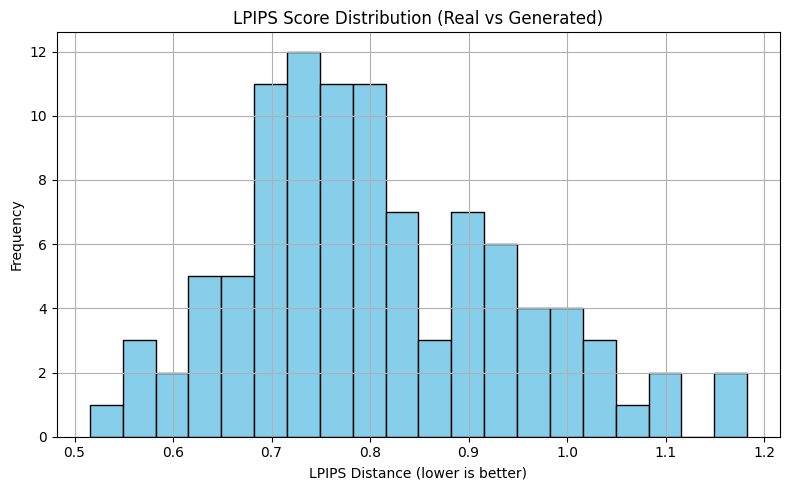

In [70]:
import os
import lpips
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Set paths
real_folder = "data/augmentedData/unspecified"
fake_folder = "data/postProcessed"

# Load LPIPS model
loss_fn = lpips.LPIPS(net='alex')  # You can also try 'vgg'

# Define image transform (LPIPS expects normalized tensors)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Collect images
real_images = sorted([f for f in os.listdir(real_folder) if f.endswith(('.png', '.jpg'))])
fake_images = sorted([f for f in os.listdir(fake_folder) if f.endswith(('.png', '.jpg'))])

# Compute LPIPS distances
lpips_scores = []
N = min(100, len(real_images), len(fake_images))  # Limit for quick comparison

for i in range(N):
    real_path = os.path.join(real_folder, real_images[i])
    fake_path = os.path.join(fake_folder, fake_images[i])

    img1 = transform(Image.open(real_path).convert("RGB")).unsqueeze(0)
    img2 = transform(Image.open(fake_path).convert("RGB")).unsqueeze(0)

    with torch.no_grad():
        dist = loss_fn(img1, img2).item()
    lpips_scores.append(dist)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(lpips_scores, bins=20, color='skyblue', edgecolor='black')
plt.title("LPIPS Score Distribution (Real vs Generated)")
plt.xlabel("LPIPS Distance (lower is better)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


/home/exouser/genai-project/cultural-heritage-ai/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/exouser/genai-project/cultural-heritage-ai/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


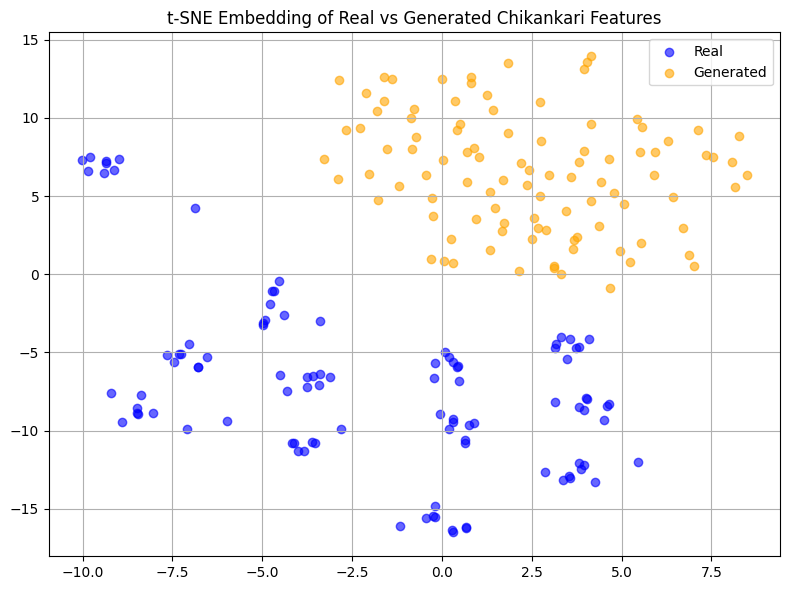

In [80]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from sklearn.manifold import TSNE
# import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Paths to image folders
real_dir = "data/augmentedData/unspecified"
fake_dir = "data/postProcessed"

# Load image paths
real_paths = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(('.jpg', '.png'))])
fake_paths = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith(('.jpg', '.png'))])

# Use smaller samples for performance
sample_size = 100
real_paths = real_paths[:sample_size]
fake_paths = fake_paths[:sample_size]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # Imagenet mean
                         [0.229, 0.224, 0.225])  # Imagenet std
])

# Load pretrained model
model = resnet50(pretrained=True)
model.fc = torch.nn.Identity()  # Remove classification head
model.eval()

def extract_features(image_paths):
    features = []
    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB")
            tensor = transform(img).unsqueeze(0)
            with torch.no_grad():
                feat = model(tensor).squeeze().numpy()
            features.append(feat)
        except:
            continue
    return np.array(features)

# Extract features
real_features = extract_features(real_paths)
fake_features = extract_features(fake_paths)

# Combine and label
all_features = np.vstack([real_features, fake_features])
labels = np.array([0] * len(real_features) + [1] * len(fake_features))  # 0=real, 1=fake

# UMAP or t-SNE
reducer = TSNE(n_components=2, random_state=42)

embeddings = reducer.fit_transform(all_features)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(embeddings[labels==0, 0], embeddings[labels==0, 1], c='blue', label='Real', alpha=0.6)
plt.scatter(embeddings[labels==1, 0], embeddings[labels==1, 1], c='orange', label='Generated', alpha=0.6)
plt.title("t-SNE Embedding of Real vs Generated Chikankari Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
